In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel("sleep_health.xlsx")
print(df.head())
print(df.info())
print(df.isnull().sum())

   person_id   age  gender         occupation   bmi country  \
0        1.0  29.0  Female             Driver  25.7   Japan   
1        2.0  55.0  Female  Software Engineer  22.0     USA   
2        3.0  42.0    Male              Nurse  25.0   India   
3        4.0  37.0  Female            Student  29.5   India   
4        5.0  23.0    Male             Lawyer  23.6   Spain   

   sleep_duration_hrs  sleep_quality_score  rem_percentage  \
0                6.19                  6.6            22.5   
1                8.32                  6.9            26.9   
2                3.74                  1.0            20.2   
3                6.79                  6.4            17.7   
4                5.02                  3.2            23.3   

   deep_sleep_percentage  ...  heart_rate_resting_bpm  sleep_aid_used  \
0                   19.3  ...                    63.0             0.0   
1                   14.9  ...                    52.0             1.0   
2                   16.2  ...

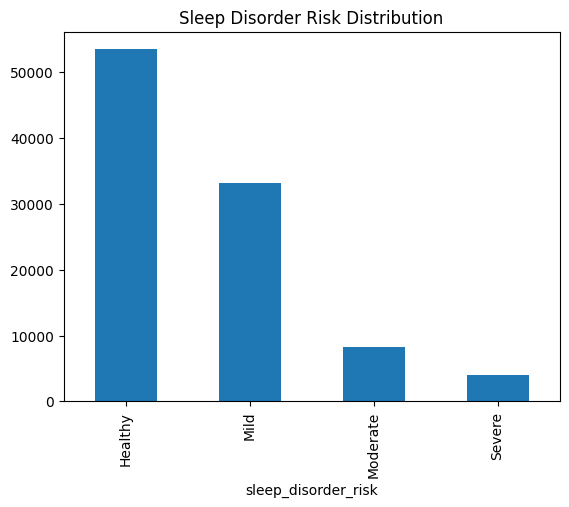

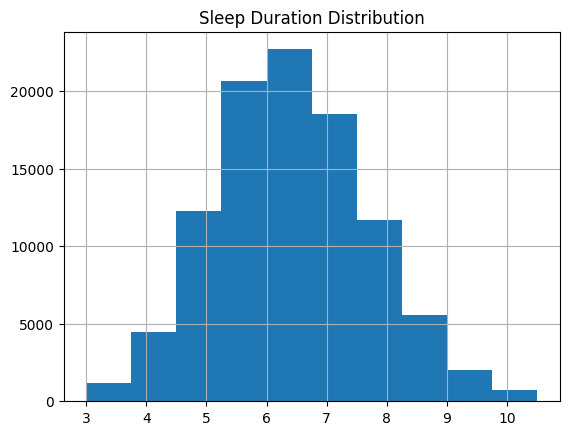

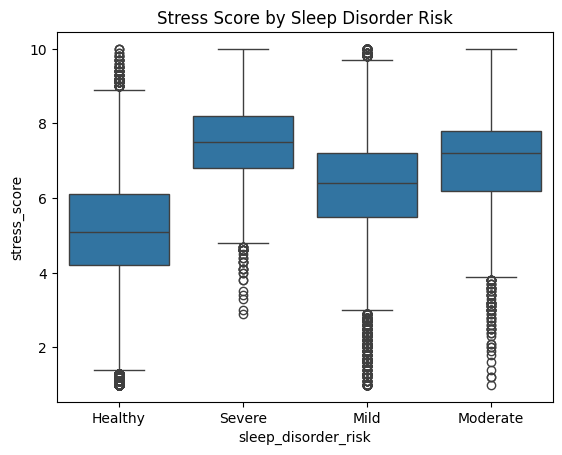

In [6]:
target ="sleep_disorder_risk"
df[target].value_counts().plot(kind='bar')
plt.title("Sleep Disorder Risk Distribution")
plt.show()

df['sleep_duration_hrs'].hist()
plt.title("Sleep Duration Distribution")
plt.show()

sns.boxplot(x=target, y='stress_score', data=df)
plt.title("Stress Score by Sleep Disorder Risk")
plt.show()


In [7]:
df = df.drop(columns=['person_id'])
df= df.dropna(subset=[target])

X= df.drop(columns=[target])
y= df[target]


In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=42, stratify=y)

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

catergorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
preprocessor = ColumnTransformer([
        ('num', numeric_transformer, numeric_features),
        ('cat', catergorical_transformer, categorical_features)
    ])



In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logisitc Regression": LogisticRegression(max_iter=1000),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
}

for name, model in models.items():
  clf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', model)
  ])
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)

  print("\n===", name, "===")
  print("Accuracy:", accuracy_score(y_test, y_pred))
  print(classification_report(y_test, y_pred))


=== Logisitc Regression ===
Accuracy: 0.8311497799585209
              precision    recall  f1-score   support

     Healthy       0.91      0.92      0.91     10701
        Mild       0.77      0.79      0.78      6623
    Moderate       0.58      0.50      0.54      1642
      Severe       0.76      0.69      0.73       803

    accuracy                           0.83     19769
   macro avg       0.75      0.73      0.74     19769
weighted avg       0.83      0.83      0.83     19769


=== Gradient Boosting ===
Accuracy: 0.911781071374374
              precision    recall  f1-score   support

     Healthy       0.97      0.98      0.98     10701
        Mild       0.87      0.93      0.90      6623
    Moderate       0.67      0.53      0.59      1642
      Severe       0.85      0.67      0.75       803

    accuracy                           0.91     19769
   macro avg       0.84      0.77      0.80     19769
weighted avg       0.91      0.91      0.91     19769


=== Random Fores